In [ ]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import create_engine

In [ ]:
# PostgreSQL connection details
username = 'postgres'
password = 'admin'
host = 'localhost'
port = '5432'
database = 'analytics_db'

# Create connection using create_engine (which acts as 
# the main interface between Python code and the database)
engine = create_engine(
    f'postgresql+pg8000://{username}:{password}@{host}:{port}/{database}'
    )

# Fetch the data from PostgreSQL analytics_db server - gold layer
df_raw = pd.read_sql(
    'SELECT * ' \
    'FROM gold.weather_observations',
    con=engine 
    # con=engine in pd.read_sql() tells pandas which 
    # database connection to use when executing the SQL query
)

## Inspect df

In [4]:
df_raw.head()

,station,station_name,elevation,observation_date,month_year,metric,value
0,PL000012120,Leba,2.0,2015-01-01,01-2015,TMAX,5.4
1,PL000012120,Leba,2.0,2015-01-01,01-2015,TMIN,1.2
2,PL000012120,Leba,2.0,2015-01-01,01-2015,PRCP,0.0
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0
4,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TMAX,1.5


In [5]:
df_raw['metric'].unique()

<StringArray>
['TMAX', 'TMIN', 'PRCP', 'TAVG', 'SNWD']
Length: 5, dtype: str

In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 137418 entries, 0 to 137417
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   station           137418 non-null  str    
 1   station_name      137418 non-null  str    
 2   elevation         137418 non-null  float64
 3   observation_date  137418 non-null  object 
 4   month_year        137418 non-null  str    
 5   metric            137418 non-null  str    
 6   value             137418 non-null  float64
dtypes: float64(2), object(1), str(4)
memory usage: 7.3+ MB


In [7]:
df_raw['observation_date'].min()

datetime.date(2015, 1, 1)

In [8]:
df_raw['observation_date'].max()

datetime.date(2026, 6, 29)

In [9]:
# Convert observation_date to date
df = df_raw.copy()
df['observation_date'] = pd.to_datetime(df['observation_date'])

In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 137418 entries, 0 to 137417
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype        
---  ------            --------------   -----        
 0   station           137418 non-null  str          
 1   station_name      137418 non-null  str          
 2   elevation         137418 non-null  float64      
 3   observation_date  137418 non-null  datetime64[s]
 4   month_year        137418 non-null  str          
 5   metric            137418 non-null  str          
 6   value             137418 non-null  float64      
dtypes: datetime64[s](1), float64(2), str(4)
memory usage: 7.3 MB


In [11]:
df_raw.isna().sum()

station             0
station_name        0
elevation           0
observation_date    0
month_year          0
metric              0
value               0
dtype: int64

In [12]:
df_raw["metric"].value_counts()

metric
TAVG    40542
PRCP    36471
TMAX    33319
TMIN    23113
SNWD     3973
Name: count, dtype: int64

In [13]:
df_raw["observation_date"].min(), df_raw["observation_date"].max()

(datetime.date(2015, 1, 1), datetime.date(2026, 6, 29))

## Analyze the trend in Poland's average annual temperature (2015-2025)

#### Extract TAVG metric

In [35]:
# Filter out TAVG metric and 2015-2025 
df = df_raw.copy()

df['observation_date'] = pd.to_datetime(df['observation_date'])

df = (df[
    (df['metric'] == 'TAVG') & 
    (df['observation_date'] < "2026-01-01")
].sort_values(
    'observation_date',
    axis=0,
    ascending=True
)
)

df

,station,station_name,elevation,observation_date,month_year,metric,value
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9
...,...,...,...,...,...,...,...
121137,PL000012385,Siedlce,152.0,2025-12-31,12-2025,TAVG,-4.1
121141,PLM00012160,Elblag-Milejewo,43.0,2025-12-31,12-2025,TAVG,-4.0
121145,PLM00012205,Szczecin,7.0,2025-12-31,12-2025,TAVG,-1.1
121149,PLM00012295,Bialystok,151.0,2025-12-31,12-2025,TAVG,-9.2


In [36]:
# Extract year from observation_date
df['year'] = df['observation_date'].dt.year

df

,station,station_name,elevation,observation_date,month_year,metric,value,year
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0,2015
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7,2015
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4,2015
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0,2015
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9,2015
...,...,...,...,...,...,...,...,...
121137,PL000012385,Siedlce,152.0,2025-12-31,12-2025,TAVG,-4.1,2025
121141,PLM00012160,Elblag-Milejewo,43.0,2025-12-31,12-2025,TAVG,-4.0,2025
121145,PLM00012205,Szczecin,7.0,2025-12-31,12-2025,TAVG,-1.1,2025
121149,PLM00012295,Bialystok,151.0,2025-12-31,12-2025,TAVG,-9.2,2025


#### Data quality assessment

To improve the reliability of the analysis, station coverage was evaluated before calculating annual average temperatures.<br>
Stations with sufficient temporal coverage across the study period were selected to minimize bias resulting from changes in station availability over time.

In [42]:
# Count the number of observations for each weather station
# to evaluate station coverage and data completeness. 
dq_count = (
    df.groupby(['station_name']).agg(
    observation_count=('month_year', 'count')).sort_values(
        'observation_count', ascending=False
    )
    )

dq_count

,observation_count
station_name,
Szczecin,4000
Bialystok,3999
Siedlce,3999
Leba,3999
Wlodawa,3999
Elblag-Milejewo,3998
Balice,3876
Lawica,3876
Okecie,3876


#### Further investigate Balice, Ławica, Okęcie and Strachowice

In [ ]:
include = [
    'Balice',
    'Lawica',
    'Okecie',
    'Strachowice'
]

df[df['station_name'] == include]

ValueError: ('Lengths must match to compare', (39498,), (4,))

#### Ten stations with the highest data completeness were selected. Four stations contained slightly fewer observations but provided coverage for major regions of Poland and were therefore retained.

In [38]:
sorted(df['station_name'].unique())

['Balice',
 'Bialystok',
 'Elblag-Milejewo',
 'Lawica',
 'Leba',
 'Okecie',
 'Siedlce',
 'Strachowice',
 'Szczecin',
 'Wlodawa']

In [48]:
# Count the number of observations for each weather station per year
# to evaluate station coverage and data completeness. 
dq_count2 = (
    df.groupby(['station_name', 'year']).agg(
    observation_count=('month_year', 'count')).sort_values(
        'observation_count', ascending=False
    )
    )

dq_count2

observation_count
station_name    year                   
Balice          2016                366
                2020                366
Bialystok       2016                366
Elblag-Milejewo 2020                366
                2016                366
...                                 ...
Leba            2024                355
Lawica          2025                236
Balice          2025                236
Okecie          2025                236
Strachowice     2025                236

[110 rows x 1 columns]

In [ ]:
# Group by year
avg_temp_agg = df.groupby(['year']).agg(
    avg_temp=('value', 'mean'))

avg_temp_agg

,avg_temp
year,
2015,9.793041
2016,9.134836
2017,8.934329
2018,9.814458
2019,10.193918
2020,9.957186
2021,8.745950
2022,9.486466
2023,10.047918


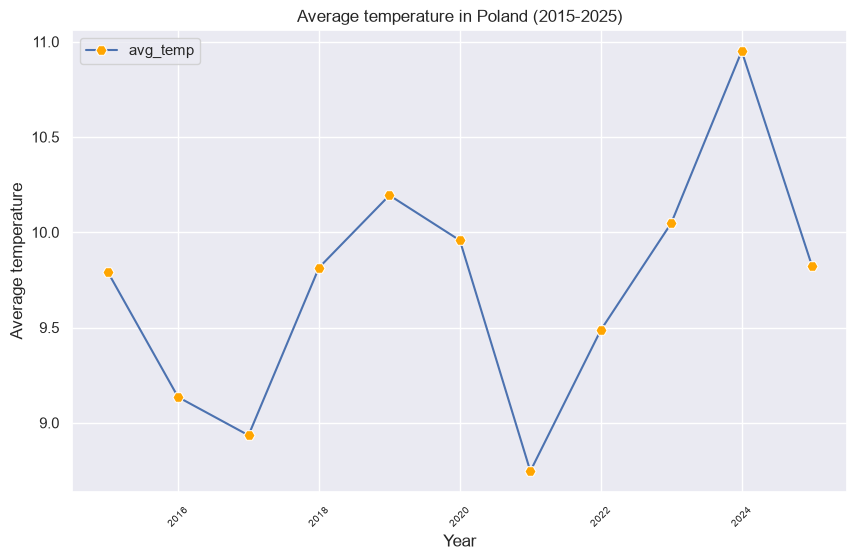

In [ ]:
# Add a grid in the background
sns.set_theme(style="darkgrid")  

# Set figure size
plt.figure(figsize=(10, 6))  

sns.lineplot(
    data=avg_temp_agg,
    marker='H',
    markersize=8,
    markerfacecolor='orange',
    color='purple'
    )

plt.title("Average temperature in Poland (2015-2025)") # Title
plt.xlabel("Year") # x-axis name
plt.ylabel("Average temperature") # y-axis name

# Rotate x-axis labels to 45 degrees and reduce labels size
plt.xticks(rotation=45, fontsize=7)

# Save plot
plt.savefig(
    r"..\02_plots\01_average_temperature.png",
    dpi=300, # Removes unnecessary whitespace around the figure
    bbox_inches="tight"
)

# Display the plot
plt.show()